In [1]:
import os
import pandas as pd
import numpy as np
import time
import gc
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from scipy.linalg import eigh
from sklearn.metrics.pairwise import pairwise_kernels

In [2]:
CONFIG = {

    'test_size_ratio': 0.40,
    'random_state': 42,


    'pca_variance': 0.90,


    'kpca_train_size': 10000,
    'test_samples_to_evaluate': 10000,


    'experiments': [
        {'kernel': 'linear', 'param': 1, 'kernel_theta': 1.0,  'name': 'Linear'},

        {'kernel': 'poly', 'param': 2, 'kernel_theta': 1.0,  'name': 'Polynomial (d=2)'},


        {'kernel': 'poly', 'param': 3, 'kernel_theta': 1.0,  'name': 'Polynomial (d=3)'},


        {'kernel': 'poly', 'param': 4, 'kernel_theta': 1.0,  'name': 'Polynomial (d=4)'},

        {'kernel': 'rbf', 'param': 0, 'kernel_theta': 10,  'name': 'RBF (sigma=10)'},
        {'kernel': 'rbf', 'param': 0, 'kernel_theta': 50,  'name': 'RBF (sigma=50)'},
        {'kernel': 'rbf', 'param': 0, 'kernel_theta': 1.5, 'name': 'RBF (sigma=1.5)'}
    ],
    'data_dir': '.',
}

In [3]:
def load_fashion_mnist_csv(data_dir):

    print(f"Φόρτωση του Fashion-MNIST από αρχεία CSV στον κατάλογο '{data_dir}'")

    train_path = os.path.join(data_dir, "fashion-mnist_train.csv")
    test_path = os.path.join(data_dir, "fashion-mnist_test.csv")

    if not os.path.exists(train_path) or not os.path.exists(test_path):
        print(f"Σφάλμα: Τα αρχεία δεν βρέθηκαν μέσα στο {os.path.abspath(data_dir)}")
        return None, None, None, None, None


    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)


    if train_df.isnull().values.any():
        print(f"Προειδοποίηση: Βρέθηκαν τιμές NaN στα δεδομένα εκπαίδευσης. Διαγραφή {train_df.isnull().any(axis=1).sum()} γραμμών")
        train_df = train_df.dropna()


    print("Επεξεργασία δεδομένων")

    X_train = train_df.iloc[:, 1:].values.astype('float32')
    y_train = train_df.iloc[:, 0].values.astype('int')

    X_test = test_df.iloc[:, 1:].values.astype('float32')
    y_test = test_df.iloc[:, 0].values.astype('int')

    label_names = [
        "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
    ]

    return X_train, y_train, X_test, y_test, label_names


X_train_raw, y_train, X_test_raw, y_test, label_names = load_fashion_mnist_csv(CONFIG['data_dir'])

if X_train_raw is not None:
    print(f"Τα δεδομένα καθαρίστηκαν και φορτώθηκαν!")
    print(f"Διαστάσεις εκπαίδευσης : {X_train_raw.shape}")

 Φόρτωση του Fashion-MNIST από αρχεία CSV στον κατάλογο '.'...
 Επεξεργασία δεδομένων...
 Τα δεδομένα καθαρίστηκαν και φορτώθηκαν!
 Διαστάσεις εκπαίδευσης : (60000, 784)


 Προβολή 10 δείγματος τυχαίων εικόνων...


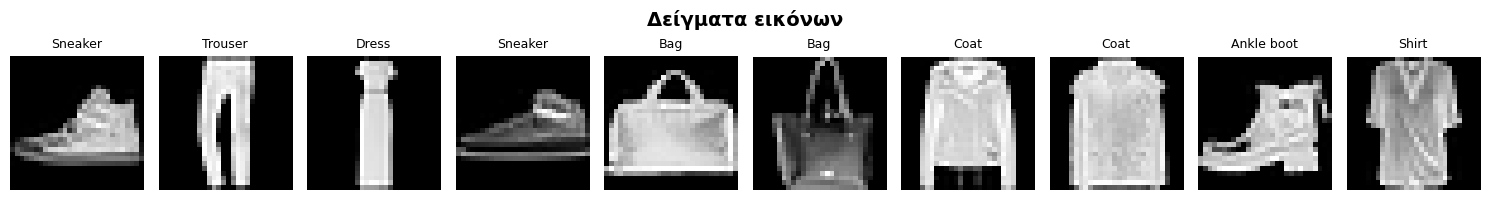

In [4]:
def show_sample_images(X, y, label_names, num_samples=10, title="Δείγματα εικόνων"):

    print(f"Προβολή {num_samples} δείγματος τυχαίων εικόνων")
    plt.figure(figsize=(num_samples * 1.5, 2))

    # Επιλογή num_samples τυχαίων δεικτών από ολόκληρο το σύνολο δεδομένων
    chosen_indices = np.random.choice(len(X), size=num_samples, replace=False)

    for i, idx in enumerate(chosen_indices):
        img = X[idx].reshape(28, 28)
        label = y[idx] # Κράτα την ετικέτα από τη διαλεγμένη εικόνα

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(label_names[label], fontsize=9)
        plt.axis("off")
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_sample_images(X_train_raw, y_train, label_names, num_samples=10)

 Εφαρμόζεται StandardScaler...
 Εφαρμόζεται PCA, κρατώντας 90.0% της διακύμανσης...
 Αρχική Διάσταση: 784
 Μειωμένη Διάσταση:  137


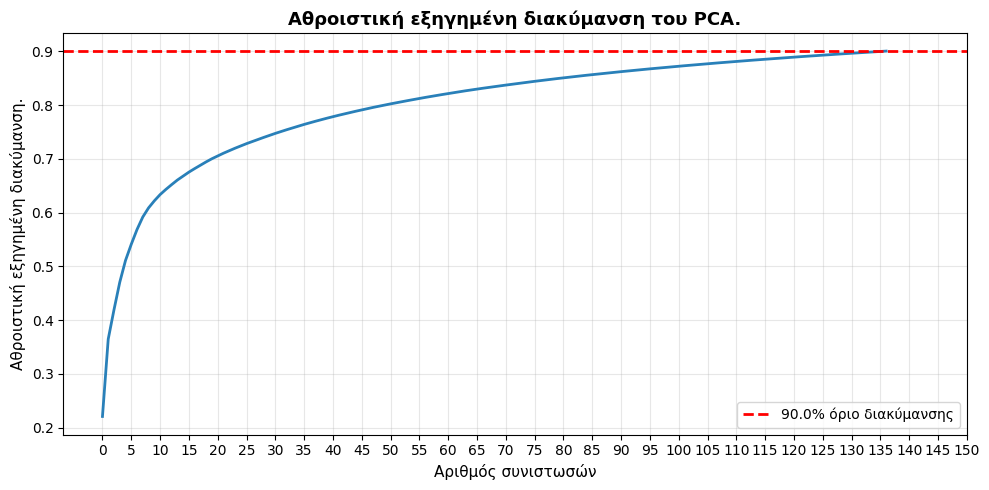

In [5]:
def preprocess_data(X_train, y_train, X_test, y_test):


    initial_train_rows = X_train.shape[0]
    initial_test_rows = X_test.shape[0]

    if np.isnan(X_train).any() or np.isinf(X_train).any():
        print("Προειδοποίηση: Βρέθηκαν τιμές NaN ή Inf  στο X_train. Αφαιρούνται τα δείγματα που εμφανίζουν NaN ή Inf.")
        nan_rows_train = np.any(np.isnan(X_train) | np.isinf(X_train), axis=1)
        X_train = X_train[~nan_rows_train]
        y_train = y_train[~nan_rows_train]
        print(f"Αφαιρέθηκαν {initial_train_rows - X_train.shape[0]} δείγματα από τα δεδομένα εκπαίδευσης.")

    if np.isnan(X_test).any() or np.isinf(X_test).any():
        print(" Προειδοποίηση: Βρέθηκαν τιμές NaN ή Inf  στο X_test. Αφαιρούνται τα δείγματα που εμφανίζουν NaN ή Inf.")
        nan_rows_test = np.any(np.isnan(X_test) | np.isinf(X_test), axis=1)
        X_test = X_test[~nan_rows_test]
        y_test = y_test[~nan_rows_test]
        print(f"Αφαιρέθηκαν {initial_test_rows - X_test.shape[0]} δείγματα από τα δεδομένα ελέγχου.")

    print("Εφαρμόζεται StandardScaler")
    scaler = StandardScaler()


    X_train_scaled = scaler.fit_transform(X_train.astype(np.float32))
    X_test_scaled = scaler.transform(X_test.astype(np.float32))


    print(f"Εφαρμόζεται PCA, κρατώντας {CONFIG['pca_variance'] * 100}% της διακύμανσης")
    pca = PCA(n_components=CONFIG['pca_variance'], random_state=CONFIG['random_state'])


    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print(f"Αρχική Διάσταση: {X_train.shape[1]}")
    print(f"Μειωμένη Διάσταση:  {X_train_pca.shape[1]}")



    cum_var = np.cumsum(pca.explained_variance_ratio_)
    plt.figure(figsize=(10, 5))
    plt.plot(cum_var, linewidth=2, color='b')
    plt.xticks(np.arange(0, 151, 5))
    plt.axhline(CONFIG['pca_variance'], linestyle='--', color='red', linewidth=2,
                label=f"{CONFIG['pca_variance'] * 100}% όριο διακύμανσης")
    plt.xlabel("Αριθμός συνιστωσών", fontsize=11)
    plt.ylabel("Αθροιστική εξηγημένη διακύμανση.", fontsize=11)
    plt.title("Αθροιστική εξηγημένη διακύμανση του PCA.", fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


    return {
        'X_train_pca': X_train_pca,
        'y_train': y_train,
        'X_test_pca': X_test_pca,
        'y_test': y_test,
        'label_names': label_names
    }


data = preprocess_data(X_train_raw, y_train, X_test_raw, y_test)

In [6]:
def train_ckfd(X_train_pca, y_train, exp_config):
    """
    ΕΙΣΟΔΟΣ:
    - X_train_pca: Τα δεδομένα σου μετά το PCA (134 διαστάσεις).
    - y_train: Οι ετικέτες.
    - exp_config: Ρυθμίσεις πειράματος (kernel, theta).
    """


    #  KPCA Transformation
    # Υπολογισμός και κεντροποίηση του Gram Matrix R

    kernel_kwargs = {'metric': exp_config['kernel']}

    if exp_config['kernel'] == 'poly':
        kernel_kwargs['degree'] = exp_config['param']
        kernel_kwargs['coef0'] = exp_config['kernel_theta']

    elif exp_config['kernel'] == 'rbf':
        sigma = exp_config['kernel_theta']
        if sigma > 0:
            kernel_kwargs['gamma'] = 1.0 / (2.0 * sigma**2)
        else:
            kernel_kwargs['gamma'] = 1.0
            print(f"Προειδοποίηση: Η παράμετρος sigma του RBF (kernel_theta) δεν είναι θετική, γίνεται χρήση της προεπιλεγμένης τιμής gamma={kernel_kwargs['gamma']}")




    K = pairwise_kernels(X_train_pca, **kernel_kwargs)

    M = K.shape[0]
    one_M = np.ones((M, M)) / M
    K_centered = K - one_M @ K - K @ one_M + one_M @ K @ one_M

    # Ιδιοανάλυση του R για εύρεση του χώρου προβολής
    eigvals, eigvecs = eigh(K_centered)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

    # Κρατάμε τις m θετικές ιδιοτιμές
    pos_idx = eigvals > 1e-6
    eigvals, eigvecs = eigvals[pos_idx], eigvecs[:, pos_idx]

    # Προβολή των δειγμάτων στον KPCA χώρο: Y = P^T * Phi(X)
    Y_train = (eigvecs / np.sqrt(eigvals)).T @ K_centered
    Y_train = Y_train.T # Διάσταση: M x m

    #  Scatter Matrices (Sw, Sb) στον KPCA χώρο
    m = Y_train.shape[1]
    classes = np.unique(y_train)
    mean_overall = np.mean(Y_train, axis=0)
    S_w, S_b = np.zeros((m, m)), np.zeros((m, m))

    for c in classes:
        Y_c = Y_train[y_train == c]
        mean_c = np.mean(Y_c, axis=0)
        S_w += (Y_c - mean_c).T @ (Y_c - mean_c)
        diff = (mean_c - mean_overall).reshape(-1, 1)
        S_b += len(Y_c) * (diff @ diff.T)

    S_w, S_b = S_w / M, S_b / M

    #  Regular & Irregular Subspaces
    w_eigvals, w_eigvecs = eigh(S_w)
    idx_w = np.argsort(w_eigvals)[::-1]
    w_eigvals, w_eigvecs = w_eigvals[idx_w], w_eigvecs[:, idx_w]

    # Επιλογή q για το Range Space (Regular)
    q = np.sum(w_eigvals > (np.max(w_eigvals) / 2000))
    P1, P2 = w_eigvecs[:, :q], w_eigvecs[:, q:]

    #  Regular features (z1)
    reg_eigvals, reg_eigvecs = eigh(P1.T @ S_b @ P1, P1.T @ S_w @ P1)
    U = reg_eigvecs[:, -len(classes)+1:]

    #  Irregular features (z2)
    irreg_eigvals, irreg_eigvecs = eigh(P2.T @ S_b @ P2)
    V = irreg_eigvecs[:, -len(classes)+1:]

    return {
        'Z1_train': Y_train @ P1 @ U, 'Z2_train': Y_train @ P2 @ V,
        'X_train_pca': X_train_pca, 'y_train': y_train, 'K_train': K,
        'eigvecs_kpca': eigvecs, 'eigvals_kpca': eigvals,
        'P1': P1, 'U': U, 'P2': P2, 'V': V, 'config': exp_config
    }


In [7]:
def test_ckfd(X_test_pca, model):
    """
    ΕΙΣΟΔΟΣ:
    - X_test_pca: Τα δεδομένα ελέγχου μετά το PCA (134 διαστάσεις).
    - model: Το λεξικό που επιστρέφει η train_ckfd.
    """
    # Προβολή του Test Set στον KPCA χώρο

    kernel_kwargs = {'metric': model['config']['kernel']}

    if model['config']['kernel'] == 'poly':
        kernel_kwargs['degree'] = model['config']['param']
        kernel_kwargs['coef0'] = model['config']['kernel_theta']

    elif model['config']['kernel'] == 'rbf':
        if model['config']['kernel_theta'] > 0:
            kernel_kwargs['gamma'] = 1.0 / (2.0 * (model['config']['kernel_theta']**2))
        else:
            kernel_kwargs['gamma'] = 1.0
            print(f"Προειδοποίηση: Η παράμετρος sigma του RBF (kernel_theta) δεν είναι θετική, γίνεται χρήση της προεπιλεγμένης τιμής gamma={kernel_kwargs['gamma']}")

    K_test = pairwise_kernels(X_test_pca, model['X_train_pca'], **kernel_kwargs)

    M = model['K_train'].shape[0]
    one_M_test = np.ones((len(X_test_pca), M)) / M
    one_M = np.ones((M, M)) / M

    # Κεντροποίηση του Test Kernel
    K_test_centered = K_test - one_M_test @ model['K_train'] - K_test @ one_M + one_M_test @ model['K_train'] @ one_M
    Y_test = K_test_centered @ (model['eigvecs_kpca'] / np.sqrt(model['eigvals_kpca']))

    # Εξαγωγή χαρακτηριστικών z1 και z2
    Z1_test = Y_test @ model['P1'] @ model['U']
    Z2_test = Y_test @ model['P2'] @ model['V']


   # 1. Συνένωση των υποχώρων (Fusion) για Train και Test δεδομένα
    X_train_fused = np.hstack([model['Z1_train'], model['Z2_train']])
    X_test_fused = np.hstack([Z1_test, Z2_test])

    # 2. Ορισμός του ταξινομητή για 1-Nearest Neighbor
    knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')

    # 3. Εκπαίδευση και Πρόβλεψη
    knn.fit(X_train_fused, model['y_train'])
    y_pred = knn.predict(X_test_fused)

    return y_pred


In [8]:
# 1. Χωρίζουμε τα ήδη υπάρχοντα PCA δεδομένα εκπαίδευσης σε Train και Validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    data['X_train_pca'][:CONFIG['kpca_train_size']],
    data['y_train'][:CONFIG['kpca_train_size']],
    test_size=CONFIG['test_size_ratio'],
    random_state=42
)

best_acc = -1
best_exp_config = None



for exp in CONFIG['experiments']:
    start_train = time.time()
    model_temp = train_ckfd(X_train_sub, y_train_sub, exp)
    train_duration = time.time() - start_train

    # Πρόβλεψη στα δεδομένα ΕΚΠΑΙΔΕΥΣΗΣ
    y_train_pred = test_ckfd(X_train_sub, model_temp)
    train_acc = accuracy_score(y_train_sub, y_train_pred)

    # Πρόβλεψη στα δεδομένα VALIDATION
    y_val_pred = test_ckfd(X_val, model_temp)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"{exp['name']:<20} | Train: {train_acc:.2%} | Val: {val_acc:.2%} | Time: {train_duration:.2f}s")

    if val_acc > best_acc:
        best_acc = val_acc
        best_exp_config = exp

print(f"\nΝικητής: {best_exp_config['name']} με Validation Accuracy: {best_acc:.2%}")

#  REFIT (Επανεκπαίδευση στο 100% των δεδομένων)
print(f"\nRefit σε όλα τα δεδομένα ({CONFIG['kpca_train_size']} δείγματα) ")
start_refit = time.time()
final_model = train_ckfd(
    data['X_train_pca'][:CONFIG['kpca_train_size']],
    data['y_train'][:CONFIG['kpca_train_size']],
    best_exp_config
)
refit_duration = time.time() - start_refit
print(f"Συνολικός χρόνος Refit: {refit_duration:.2f} δευτερόλεπτα.")



Linear               | Train: 100.00% | Val: 78.50% | Time: 198.66s
Polynomial (d=2)     | Train: 100.00% | Val: 81.12% | Time: 308.09s
Polynomial (d=3)     | Train: 100.00% | Val: 79.07% | Time: 333.70s
Polynomial (d=4)     | Train: 100.00% | Val: 73.30% | Time: 678.53s
RBF (sigma=10)       | Train: 100.00% | Val: 80.45% | Time: 338.61s
RBF (sigma=50)       | Train: 100.00% | Val: 80.70% | Time: 311.94s
RBF (sigma=1.5)      | Train: 100.00% | Val: 12.45% | Time: 386.22s

Νικητής: Polynomial (d=2) με Validation Accuracy: 81.12%

 Refit σε όλα τα δεδομένα (10000 δείγματα) 
Συνολικός χρόνος Refit: 1197.07 δευτερόλεπτα.


In [9]:
#  ΤΕΛΙΚΟ TEST
y_train_final_pred = test_ckfd(data['X_train_pca'][:CONFIG['kpca_train_size']], final_model)
final_train_acc = accuracy_score(data['y_train'][:CONFIG['kpca_train_size']], y_train_final_pred)

start_test = time.time()
y_test_pred = test_ckfd(data['X_test_pca'][:CONFIG['test_samples_to_evaluate']], final_model)
test_duration = time.time() - start_test

final_test_acc = accuracy_score(data['y_test'][:CONFIG['test_samples_to_evaluate']], y_test_pred)

print(f"ΤΕΛΙΚΟ TRAINING ACCURACY: {final_train_acc:.2%}")
print(f"ΤΕΛΙΚΟ TEST ACCURACY: {final_test_acc:.2%}") # Εμφάνιση τελικού test ως ποσοστό
print(f"Χρόνος Τελικής Πρόβλεψης: {test_duration:.2f}s")


ΤΕΛΙΚΟ TRAINING ACCURACY: 100.00%
ΤΕΛΙΚΟ TEST ACCURACY: 82.44%
Χρόνος Τελικής Πρόβλεψης: 357.98s


In [10]:
y_true_test = data['y_test'][:CONFIG['test_samples_to_evaluate']]

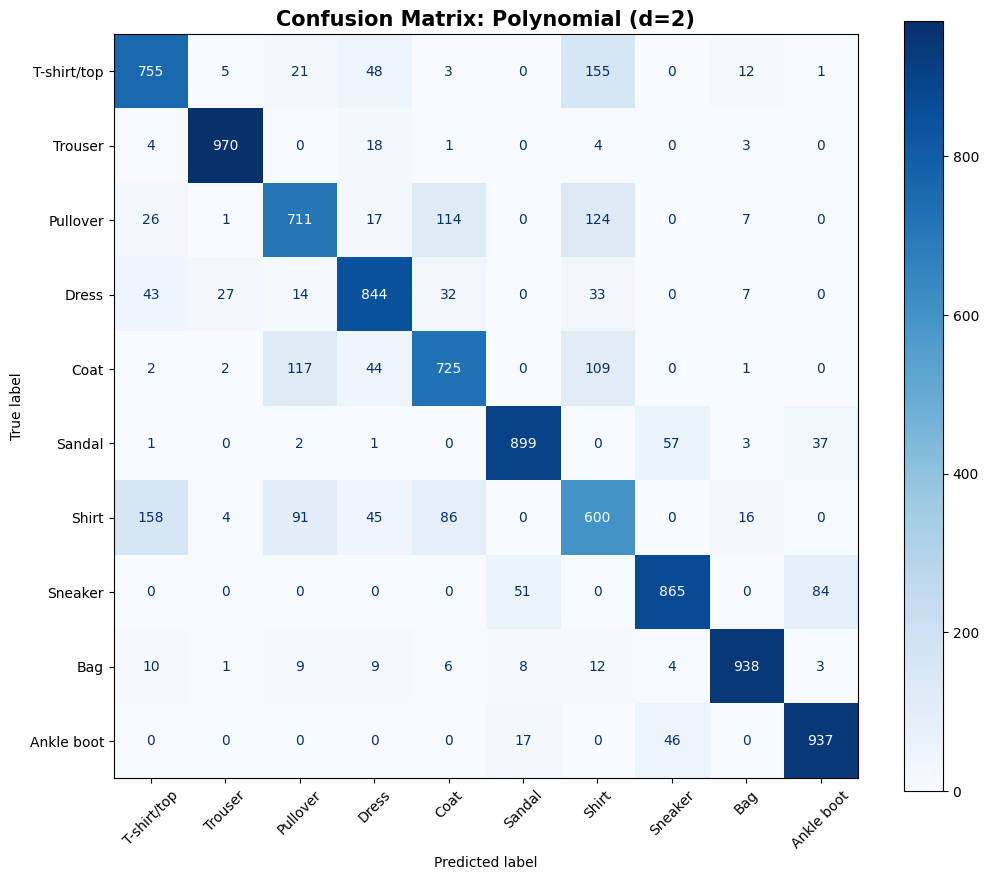

In [11]:
cm = confusion_matrix(y_true_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data['label_names'])
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(xticks_rotation=45, cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix: {best_exp_config['name']}", fontsize=15, fontweight='bold')
plt.show()

In [12]:
print(classification_report(y_true_test, y_test_pred, target_names=data['label_names']))

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.76      0.76      1000
     Trouser       0.96      0.97      0.97      1000
    Pullover       0.74      0.71      0.72      1000
       Dress       0.82      0.84      0.83      1000
        Coat       0.75      0.72      0.74      1000
      Sandal       0.92      0.90      0.91      1000
       Shirt       0.58      0.60      0.59      1000
     Sneaker       0.89      0.86      0.88      1000
         Bag       0.95      0.94      0.94      1000
  Ankle boot       0.88      0.94      0.91      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [13]:
def show_correct_examples(y_pred, num_samples=5, title="Παραδείγματα Ορθής Κατηγοριοποίησης"):
    """Εμφανίζει τυχαία δείγματα που το μοντέλο βρήκε σωστά."""
    # Χρησιμοποιούμε το y_pred που δίνουμε ως παράμετρο
    indices = np.where(y_pred == y_true_test)[0]

    if len(indices) == 0:
        print("Δεν βρέθηκαν σωστές προβλέψεις.")
        return

    chosen = np.random.choice(indices, size=min(num_samples, len(indices)), replace=False)

    plt.figure(figsize=(num_samples * 2.5, 3))
    for i, idx in enumerate(chosen):
        img = X_test_raw[idx].reshape(28, 28)
        label = data['label_names'][y_true_test[idx]]
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Σωστό: {label}", color='green', fontsize=10)
        plt.axis("off")
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.show()

In [15]:
def show_incorrect_examples(y_pred, num_samples=5, title="Παραδείγματα Εσφαλμένης Κατηγοριοποίησης"):
    """Εμφανίζει τυχαία δείγματα που το μοντέλο απέτυχε να βρει."""
    # Χρησιμοποιούμε το y_pred που δίνουμε ως παράμετρο
    indices = np.where(y_pred != y_true_test)[0]

    if len(indices) == 0:
        print("Δεν βρέθηκαν λάθη.")
        return

    chosen = np.random.choice(indices, size=min(num_samples, len(indices)), replace=False)

    plt.figure(figsize=(num_samples * 2.5, 3))
    for i, idx in enumerate(chosen):
        img = X_test_raw[idx].reshape(28, 28)
        true_label = data['label_names'][y_true_test[idx]]
        pred_label = data['label_names'][y_pred[idx]] # Πρόβλεψη από το y_pred
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true_label}\nPred: {pred_label}", color='red', fontsize=10)
        plt.axis("off")
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.show()

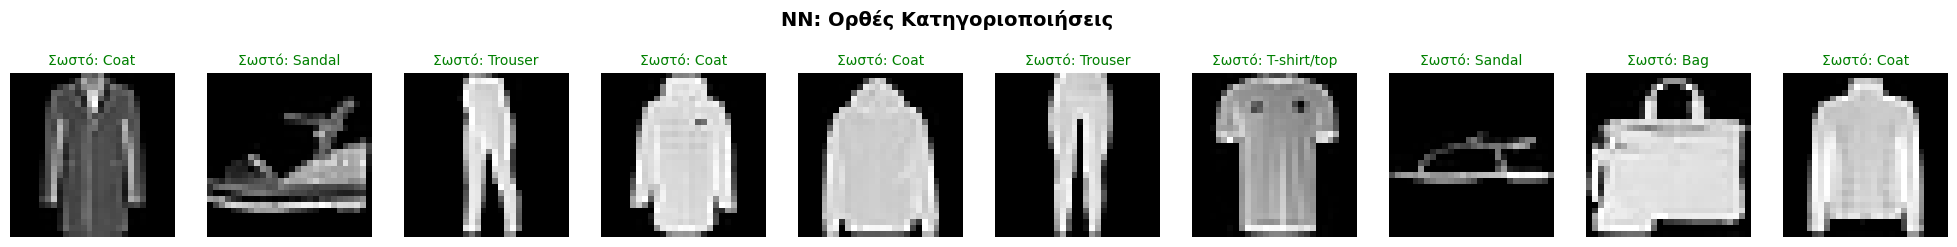

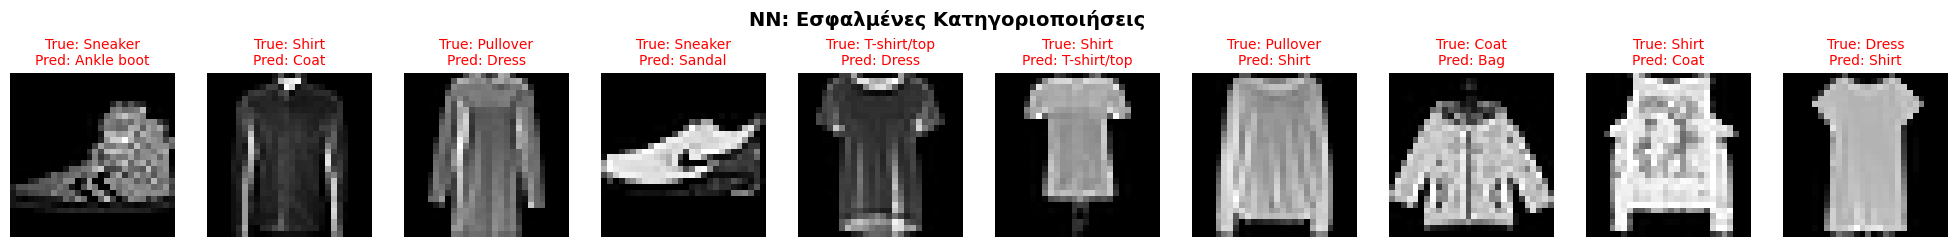

In [16]:
show_correct_examples(y_test_pred, num_samples=10, title="NN: Ορθές Κατηγοριοποιήσεις")
print('='*70)
show_incorrect_examples(y_test_pred, num_samples=10, title="NN: Εσφαλμένες Κατηγοριοποιήσεις")

In [17]:
def evaluate_ncc_ckfd(X_test_pca, y_test, model, label_names):
    """
    Υπολογίζει το NCC πάνω στα χαρακτηριστικά του CKFD (KPCA+LDA),
    εμφανίζει Confusion Matrix και Classification Report.
    """
    # --- Βήμα 1: Προβολή των Test δεδομένων στον χώρο του μοντέλου ---
    # (Η λογική είναι ίδια με την test_ckfd για την εξαγωγή των Z1, Z2)
    start_time = time.time()
    kernel_kwargs = {'metric': model['config']['kernel']}
    if model['config']['kernel'] == 'poly':
        kernel_kwargs['degree'] = model['config']['param']
        kernel_kwargs['coef0'] = model['config']['kernel_theta']
    elif model['config']['kernel'] == 'rbf':
        kernel_kwargs['gamma'] = 1.0 / (2.0 * (model['config']['kernel_theta']**2))

    # Υπολογισμός Kernel Matrix και κεντροποίηση
    K_test = pairwise_kernels(X_test_pca, model['X_train_pca'], **kernel_kwargs)
    M = model['K_train'].shape[0]
    one_M_test = np.ones((len(X_test_pca), M)) / M
    one_M = np.ones((M, M)) / M
    K_test_centered = K_test - one_M_test @ model['K_train'] - K_test @ one_M + one_M_test @ model['K_train'] @ one_M

    # Προβολή στον KPCA χώρο
    Y_test = K_test_centered @ (model['eigvecs_kpca'] / np.sqrt(model['eigvals_kpca']))

    # Εξαγωγή χαρακτηριστικών Z1 και Z2 (Test)
    Z1_test = Y_test @ model['P1'] @ model['U']
    Z2_test = Y_test @ model['P2'] @ model['V']

    # Fusion των χαρακτηριστικών για το NCC (Concatenation)
    X_test_fused = np.hstack([Z1_test, Z2_test])
    X_train_fused = np.hstack([model['Z1_train'], model['Z2_train']])

    # --- Βήμα 2: Εκπαίδευση και Πρόβλεψη NCC ---
    ncc = NearestCentroid()
    ncc.fit(X_train_fused, model['y_train'])
    y_train_pred = ncc.predict(X_train_fused)
    train_acc = accuracy_score(model['y_train'], y_train_pred)

    # Πρόβλεψη στο Test Set
    y_pred = ncc.predict(X_test_fused)

    end_time = time.time()
    duration = end_time - start_time

    # --- Βήμα 3: Αποτελέσματα ---
    test_acc = accuracy_score(y_test, y_pred)


    print(f"Training Accuracy: {train_acc:.2%}")
    print(f"Test Accuracy:     {test_acc:.2%}")
    print(f"Χρόνος Εκτέλεσης NCC: {duration:.2f} δευτερόλεπτα")

    return y_pred


Training Accuracy: 86.98%
Test Accuracy:     85.24%
Χρόνος Εκτέλεσης NCC: 395.13 δευτερόλεπτα


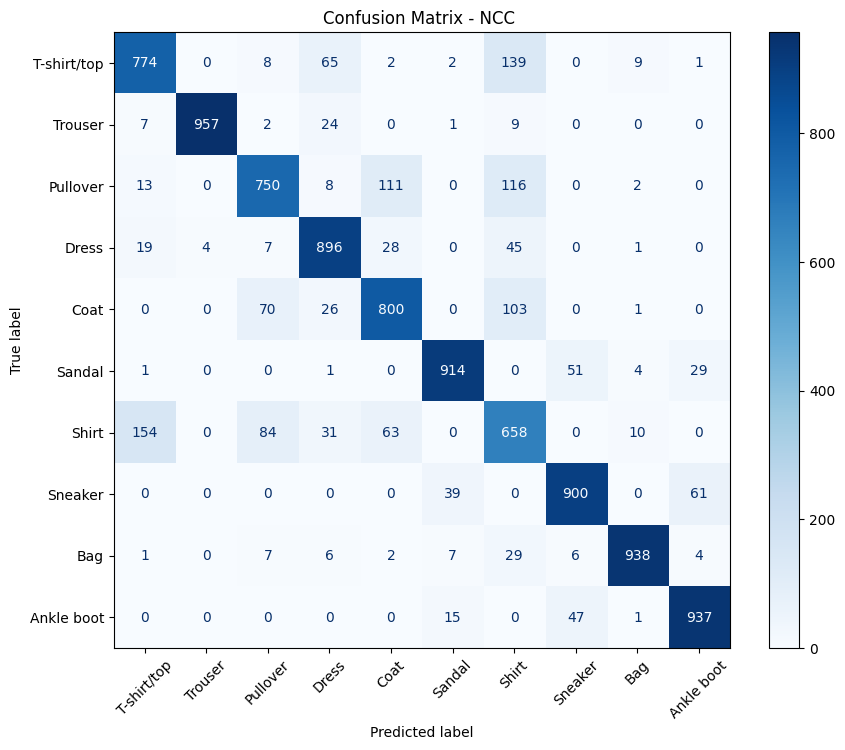

In [18]:
y_pred_ncc = evaluate_ncc_ckfd(data['X_test_pca'][:CONFIG['test_samples_to_evaluate']], y_true_test, final_model, data['label_names'])
cm = confusion_matrix(y_true_test, y_pred_ncc)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f"Confusion Matrix - NCC ")
plt.show()

In [19]:
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_ncc, target_names=label_names))


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.77      0.79      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.81      0.75      0.78      1000
       Dress       0.85      0.90      0.87      1000
        Coat       0.80      0.80      0.80      1000
      Sandal       0.93      0.91      0.92      1000
       Shirt       0.60      0.66      0.63      1000
     Sneaker       0.90      0.90      0.90      1000
         Bag       0.97      0.94      0.95      1000
  Ankle boot       0.91      0.94      0.92      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



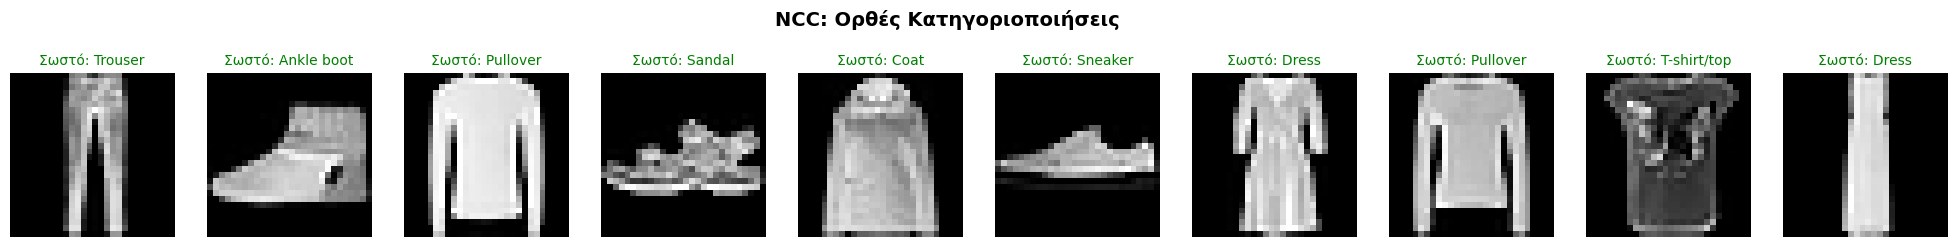

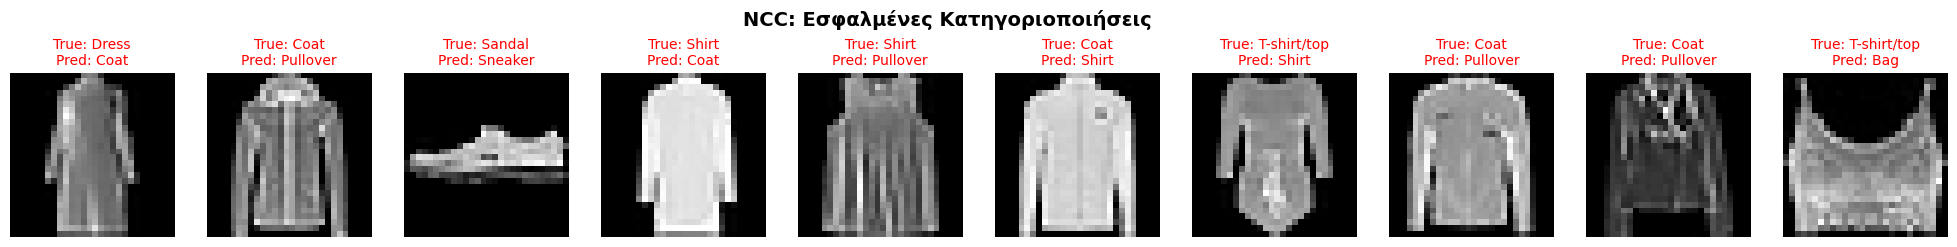

In [20]:
show_correct_examples(y_pred_ncc, num_samples=10, title="NCC: Ορθές Κατηγοριοποιήσεις")
print('='*70)
show_incorrect_examples(y_pred_ncc, num_samples=10, title="NCC: Εσφαλμένες Κατηγοριοποιήσεις")